In [202]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc
from sklearn.metrics import precision_recall_curve
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import GridSearchCV


In [203]:
# Memuat dataset
df = pd.read_csv(r"C:\kuliah\SEMESTER 6\machine learning\uts\Dataset-Mental-Disorders.csv")

# Menampilkan ukuran dataset (baris dan kolom)
print(df.shape)

(120, 19)


In [204]:
# Menampilkan 5 baris pertama dalam bentuk tabel
df.head()

,Patient Number,Sadness,Euphoric,Exhausted,Sleep dissorder,Mood Swing,Suicidal thoughts,Anorxia,Authority Respect,Try-Explanation,Aggressive Response,Ignore & Move-On,Nervous Break-down,Admit Mistakes,Overthinking,Sexual Activity,Concentration,Optimisim,Expert Diagnose
0,Patiant-01,Usually,Seldom,Sometimes,Sometimes,YES,YES,NO,NO,YES,NO,NO,YES,YES,YES,3 From 10,3 From 10,4 From 10,Bipolar Type-2
1,Patiant-02,Usually,Seldom,Usually,Sometimes,NO,YES,NO,NO,NO,NO,NO,NO,NO,NO,4 From 10,2 From 10,5 From 10,Depression
2,Patiant-03,Sometimes,Most-Often,Sometimes,Sometimes,YES,NO,NO,NO,YES,YES,NO,YES,YES,NO,6 From 10,5 From 10,7 From 10,Bipolar Type-1
3,Patiant-04,Usually,Seldom,Usually,Most-Often,YES,YES,YES,NO,YES,NO,NO,NO,NO,NO,3 From 10,2 From 10,2 From 10,Bipolar Type-2
4,Patiant-05,Usually,Usually,Sometimes,Sometimes,NO,NO,NO,NO,NO,NO,NO,YES,YES,YES,5 From 10,5 From 10,6 From 10,Normal


In [205]:
# Memeriksa kolom dalam dataset
print(df.columns)

Index(['Patient Number', 'Sadness', 'Euphoric', 'Exhausted', 'Sleep dissorder',
       'Mood Swing', 'Suicidal thoughts', 'Anorxia', 'Authority Respect',
       'Try-Explanation', 'Aggressive Response', 'Ignore & Move-On',
       'Nervous Break-down', 'Admit Mistakes', 'Overthinking',
       'Sexual Activity', 'Concentration', 'Optimisim', 'Expert Diagnose'],
      dtype='object')


In [206]:
# Menghapus kolom 'Patient Number'
df.drop('Patient Number', axis=1, inplace=True)

# Menampilkan 5 baris pertama untuk memastikan kolom telah dihapus
df.head()


,Sadness,Euphoric,Exhausted,Sleep dissorder,Mood Swing,Suicidal thoughts,Anorxia,Authority Respect,Try-Explanation,Aggressive Response,Ignore & Move-On,Nervous Break-down,Admit Mistakes,Overthinking,Sexual Activity,Concentration,Optimisim,Expert Diagnose
0,Usually,Seldom,Sometimes,Sometimes,YES,YES,NO,NO,YES,NO,NO,YES,YES,YES,3 From 10,3 From 10,4 From 10,Bipolar Type-2
1,Usually,Seldom,Usually,Sometimes,NO,YES,NO,NO,NO,NO,NO,NO,NO,NO,4 From 10,2 From 10,5 From 10,Depression
2,Sometimes,Most-Often,Sometimes,Sometimes,YES,NO,NO,NO,YES,YES,NO,YES,YES,NO,6 From 10,5 From 10,7 From 10,Bipolar Type-1
3,Usually,Seldom,Usually,Most-Often,YES,YES,YES,NO,YES,NO,NO,NO,NO,NO,3 From 10,2 From 10,2 From 10,Bipolar Type-2
4,Usually,Usually,Sometimes,Sometimes,NO,NO,NO,NO,NO,NO,NO,YES,YES,YES,5 From 10,5 From 10,6 From 10,Normal


In [207]:
# Menampilkan distribusi kelas target (Expert Diagnose)
print(df['Expert Diagnose'].value_counts())

# Menampilkan persentase distribusi kelas target
print(df['Expert Diagnose'].value_counts() / float(len(df)))


Expert Diagnose
Bipolar Type-2    31
Depression        31
Normal            30
Bipolar Type-1    28
Name: count, dtype: int64
Expert Diagnose
Bipolar Type-2    0.258333
Depression        0.258333
Normal            0.250000
Bipolar Type-1    0.233333
Name: count, dtype: float64


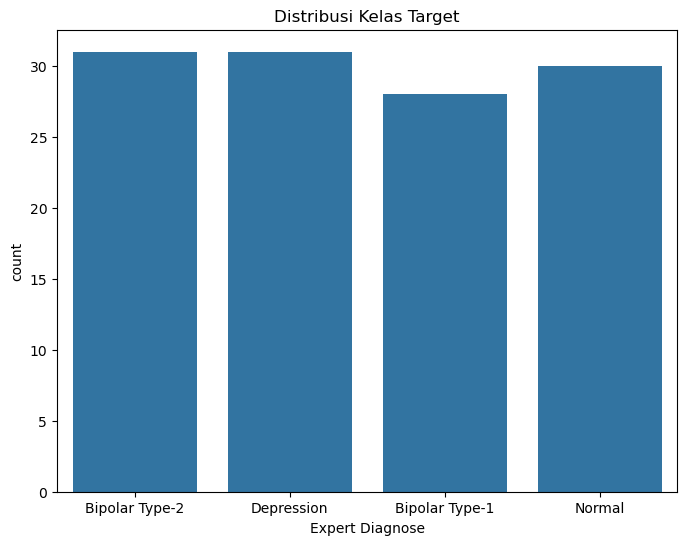

In [208]:
# Visualisasi distribusi kelas
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.countplot(x='Expert Diagnose', data=df)
plt.title('Distribusi Kelas Target')
plt.show()

In [209]:
# Mengecek data yang hilang
print(df.isnull().sum())

Sadness                0
Euphoric               0
Exhausted              0
Sleep dissorder        0
Mood Swing             0
Suicidal thoughts      0
Anorxia                0
Authority Respect      0
Try-Explanation        0
Aggressive Response    0
Ignore & Move-On       0
Nervous Break-down     0
Admit Mistakes         0
Overthinking           0
Sexual Activity        0
Concentration          0
Optimisim              0
Expert Diagnose        0
dtype: int64


In [210]:
# view summary of dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Sadness              120 non-null    object
 1   Euphoric             120 non-null    object
 2   Exhausted            120 non-null    object
 3   Sleep dissorder      120 non-null    object
 4   Mood Swing           120 non-null    object
 5   Suicidal thoughts    120 non-null    object
 6   Anorxia              120 non-null    object
 7   Authority Respect    120 non-null    object
 8   Try-Explanation      120 non-null    object
 9   Aggressive Response  120 non-null    object
 10  Ignore & Move-On     120 non-null    object
 11  Nervous Break-down   120 non-null    object
 12  Admit Mistakes       120 non-null    object
 13  Overthinking         120 non-null    object
 14  Sexual Activity      120 non-null    object
 15  Concentration        120 non-null    object
 16  Optimisi

In [211]:
# Mapping untuk gejala
ranking_map = {
    "Most-Often": 3,
    "Usually": 2,
    "Sometimes": 1,
    "Seldom": 0
}

# Menerapkan ranking map untuk kolom gejala
df['Sadness'] = df['Sadness'].map(ranking_map)
df['Euphoric'] = df['Euphoric'].map(ranking_map)
df['Exhausted'] = df['Exhausted'].map(ranking_map)
df['Sleep dissorder'] = df['Sleep dissorder'].map(ranking_map)

# Menampilkan hasil setelah perubahan
print(df[['Sadness', 'Euphoric', 'Exhausted','Sleep dissorder']].head())

   Sadness  Euphoric  Exhausted  Sleep dissorder
0        2         0          1                1
1        2         0          2                1
2        1         3          1                1
3        2         0          2                3
4        2         2          1                1


In [212]:
# Mengonversi kolom YES/NO menjadi 1/0
yes_no_columns = ['Mood Swing', 'Suicidal thoughts', 'Anorxia', 'Authority Respect', 'Try-Explanation', 
                  'Aggressive Response', 'Ignore & Move-On', 'Nervous Break-down', 'Admit Mistakes', 'Overthinking']

for col in yes_no_columns:
    df[col] = df[col].map({'YES': 1, 'NO': 0})
    df[col] = df[col].fillna(0).astype(int)  # Mengganti NaN dengan 0 dan mengonversi ke integer

# Menampilkan hasil setelah perubahan
print(df[['Mood Swing', 'Suicidal thoughts', 'Anorxia', 'Authority Respect', 'Try-Explanation', 
                  'Aggressive Response', 'Ignore & Move-On', 'Nervous Break-down', 'Admit Mistakes', 'Overthinking']].head())


   Mood Swing  Suicidal thoughts  Anorxia  Authority Respect  Try-Explanation  \
0           1                  0        0                  0                1   
1           0                  1        0                  0                0   
2           1                  0        0                  0                1   
3           1                  1        1                  0                1   
4           0                  0        0                  0                0   

   Aggressive Response  Ignore & Move-On  Nervous Break-down  Admit Mistakes  \
0                    0                 0                   1               1   
1                    0                 0                   0               0   
2                    1                 0                   1               1   
3                    0                 0                   0               0   
4                    0                 0                   1               1   

   Overthinking  
0             

In [213]:
# Fungsi untuk mengambil angka dari kolom "X From 10"
def extract_number(value):
    # Memastikan hanya memproses nilai yang merupakan string dengan format "X From 10"
    if isinstance(value, str) and 'From 10' in value:
        # Ambil angka pertama dari string
        try:
            number = int(value.split()[0])  # Ambil angka sebelum "From 10"
            return number
        except ValueError:
            return None  # Jika tidak bisa diubah menjadi angka
    return value  # Jika bukan string yang sesuai, biarkan apa adanya

# Kolom yang perlu diubah
rating_columns = ['Sexual Activity', 'Concentration', 'Optimisim']

# Menerapkan fungsi extract_number ke kolom-kolom tersebut
for col in rating_columns:
    df[col] = df[col].apply(extract_number)

# Menampilkan hasil setelah perubahan
print(df[['Sexual Activity', 'Concentration', 'Optimisim']].head())

   Sexual Activity  Concentration  Optimisim
0                3              3          4
1                4              2          5
2                6              5          7
3                3              2          2
4                5              5          6


In [214]:
# Menampilkan 5 baris pertama dalam bentuk tabel
df.head()

,Sadness,Euphoric,Exhausted,Sleep dissorder,Mood Swing,Suicidal thoughts,Anorxia,Authority Respect,Try-Explanation,Aggressive Response,Ignore & Move-On,Nervous Break-down,Admit Mistakes,Overthinking,Sexual Activity,Concentration,Optimisim,Expert Diagnose
0,2,0,1,1,1,0,0,0,1,0,0,1,1,1,3,3,4,Bipolar Type-2
1,2,0,2,1,0,1,0,0,0,0,0,0,0,0,4,2,5,Depression
2,1,3,1,1,1,0,0,0,1,1,0,1,1,0,6,5,7,Bipolar Type-1
3,2,0,2,3,1,1,1,0,1,0,0,0,0,0,3,2,2,Bipolar Type-2
4,2,2,1,1,0,0,0,0,0,0,0,1,1,1,5,5,6,Normal


In [215]:
# Menampilkan summary statistik untuk kolom numerik
df.describe()

,Sadness,Euphoric,Exhausted,Sleep dissorder,Mood Swing,Suicidal thoughts,Anorxia,Authority Respect,Try-Explanation,Aggressive Response,Ignore & Move-On,Nervous Break-down,Admit Mistakes,Overthinking,Sexual Activity,Concentration,Optimisim
count,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000
mean,1.550000,0.933333,1.633333,1.458333,0.475000,0.466667,0.383333,0.391667,0.475000,0.483333,0.416667,0.516667,0.491667,0.541667,4.741667,4.250000,4.466667
std,0.924458,0.923396,1.020243,0.977871,0.501468,0.500979,0.488237,0.490169,0.501468,0.501817,0.495074,0.501817,0.502027,0.500350,2.010459,1.797524,1.991298
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,3.000000,3.000000
50%,2.000000,1.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,5.000000,4.000000,4.000000
75%,2.000000,1.000000,2.250000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,6.000000,5.000000,6.000000
max,3.000000,3.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,9.000000,8.000000,9.000000


Text(0, 0.5, 'Optimisim')

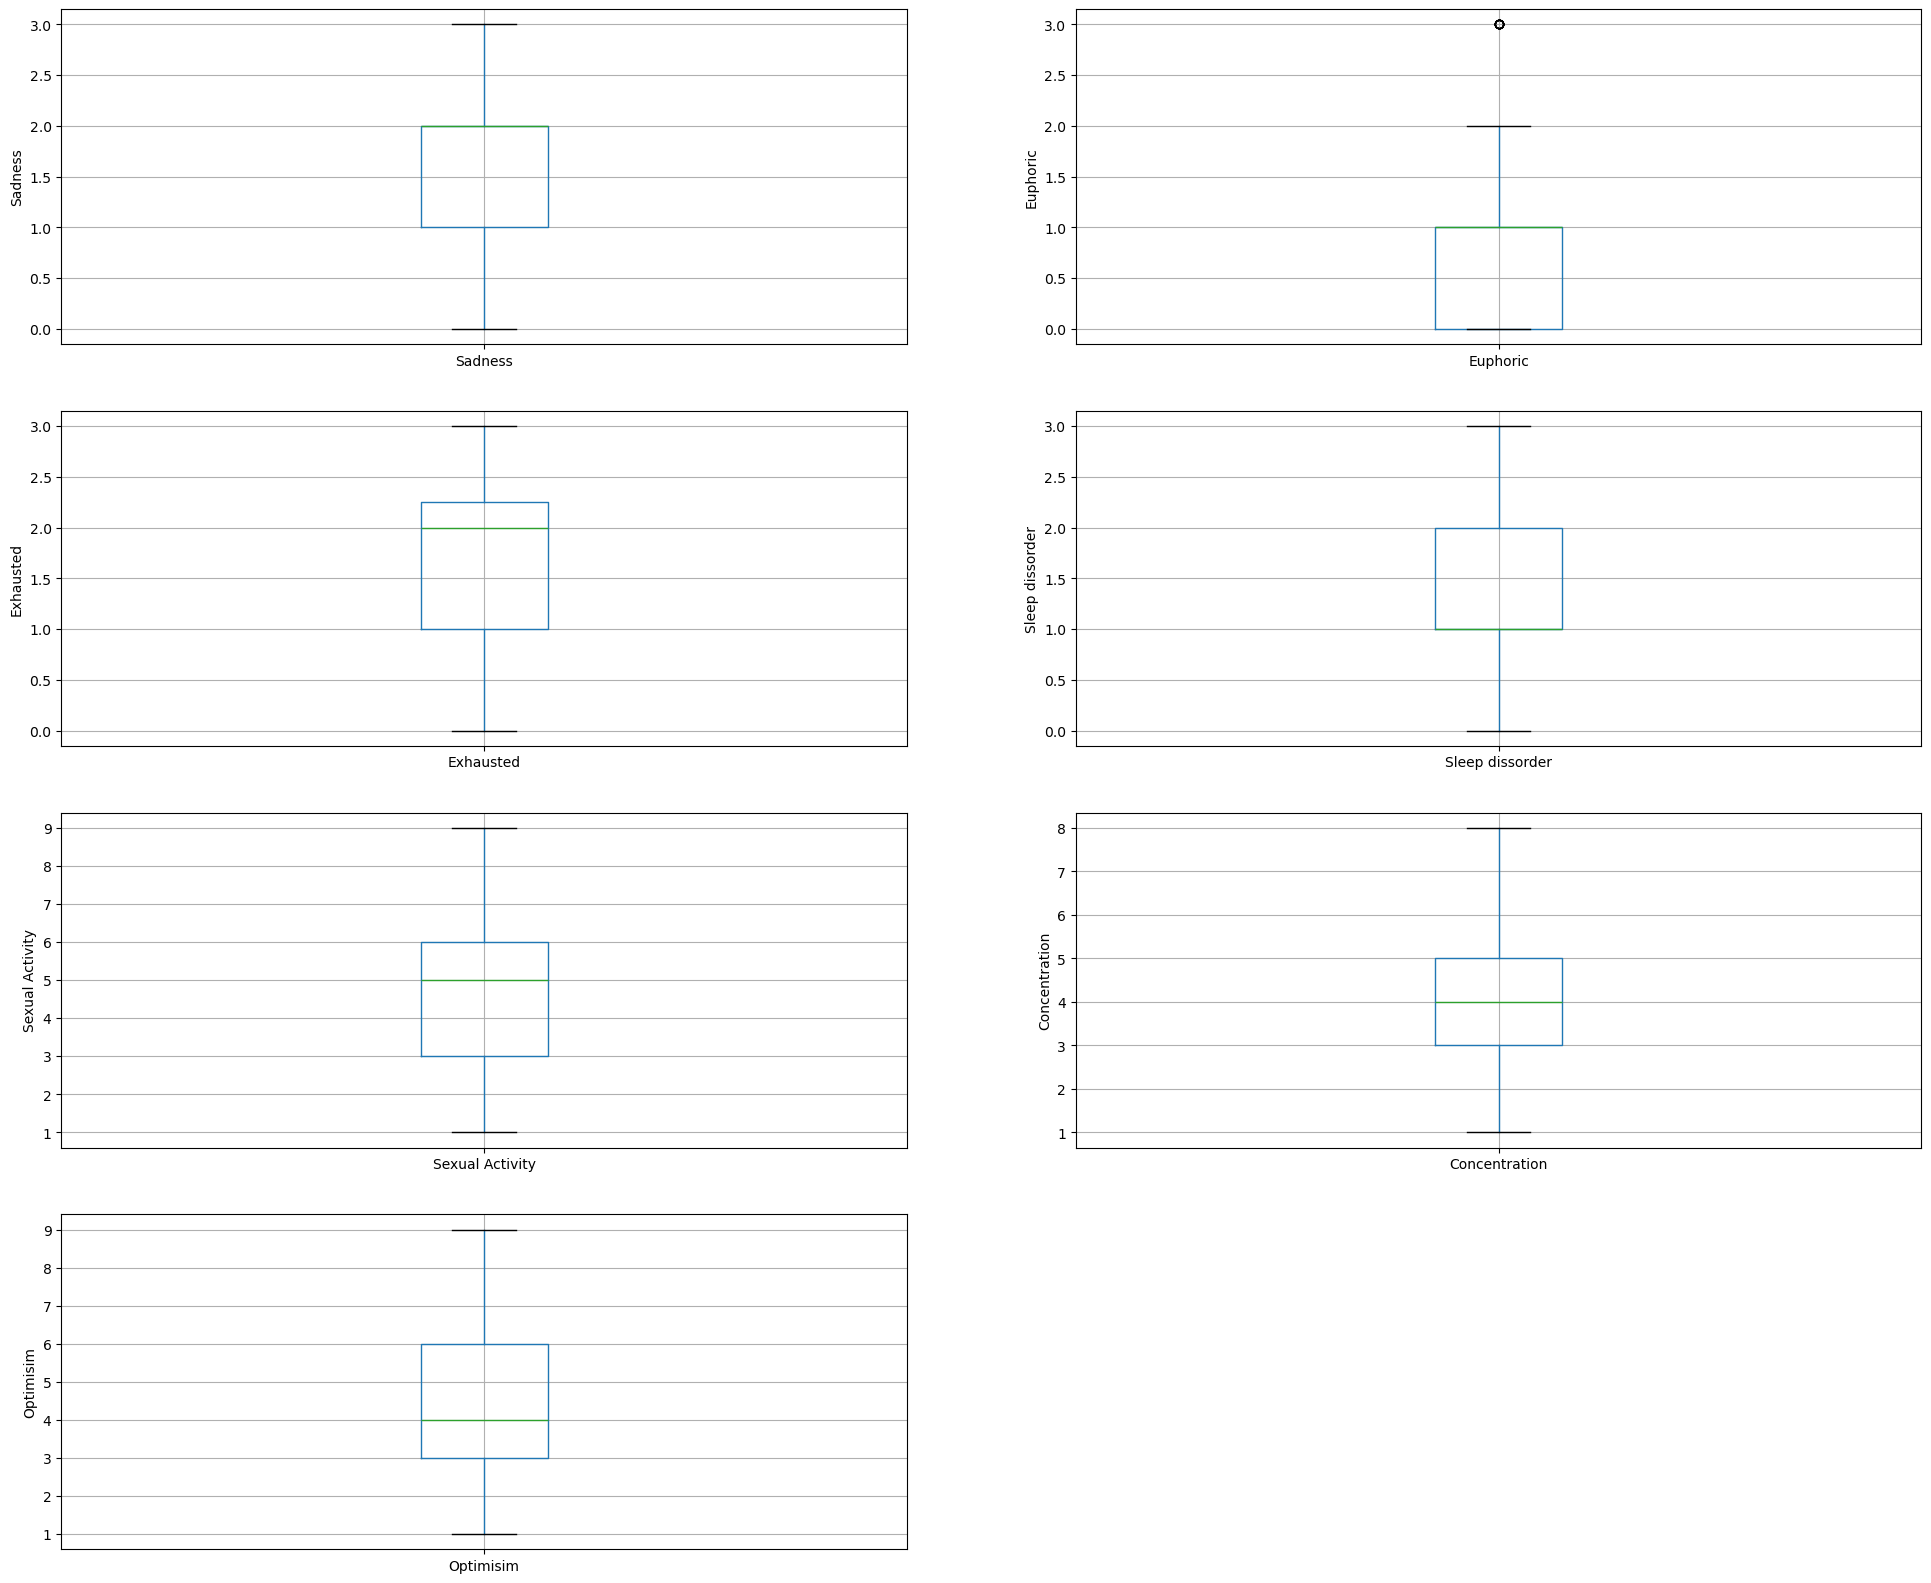

In [216]:
import matplotlib.pyplot as plt
import seaborn as sns

# draw boxplots to visualize outliers

plt.figure(figsize=(24,20))
	
plt.subplot(4, 2, 1)
fig = df.boxplot(column='Sadness')
fig.set_title('')
fig.set_ylabel('Sadness')


plt.subplot(4, 2, 2)
fig = df.boxplot(column='Euphoric')
fig.set_title('')
fig.set_ylabel('Euphoric')

plt.subplot(4, 2, 3)
fig = df.boxplot(column='Exhausted')
fig.set_title('')
fig.set_ylabel('Exhausted')

plt.subplot(4, 2, 4)
fig = df.boxplot(column='Sleep dissorder')
fig.set_title('')
fig.set_ylabel('Sleep dissorder')

plt.subplot(4, 2, 5)
fig = df.boxplot(column='Sexual Activity')
fig.set_title('')
fig.set_ylabel('Sexual Activity')

plt.subplot(4, 2, 6)
fig = df.boxplot(column='Concentration')
fig.set_title('')
fig.set_ylabel('Concentration')

plt.subplot(4, 2, 7)
fig = df.boxplot(column='Optimisim')
fig.set_title('')
fig.set_ylabel('Optimisim')


In [217]:
# Menghitung Q1 (25%) dan Q3 (75%) untuk kolom 'Euphoric'
Q1 = df['Euphoric'].quantile(0.25)
Q3 = df['Euphoric'].quantile(0.75)

# Menghitung IQR (Interquartile Range)
IQR = Q3 - Q1

# Menentukan batas bawah dan atas untuk outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Mengganti outliers dengan median
median_value = df['Euphoric'].median()
df['Euphoric'] = np.where((df['Euphoric'] < lower_bound) | (df['Euphoric'] > upper_bound), median_value, df['Euphoric'])

# Menampilkan hasil setelah mengganti outliers dengan median
print(df['Euphoric'].head())

0    0.0
1    0.0
2    1.0
3    0.0
4    2.0
Name: Euphoric, dtype: float64


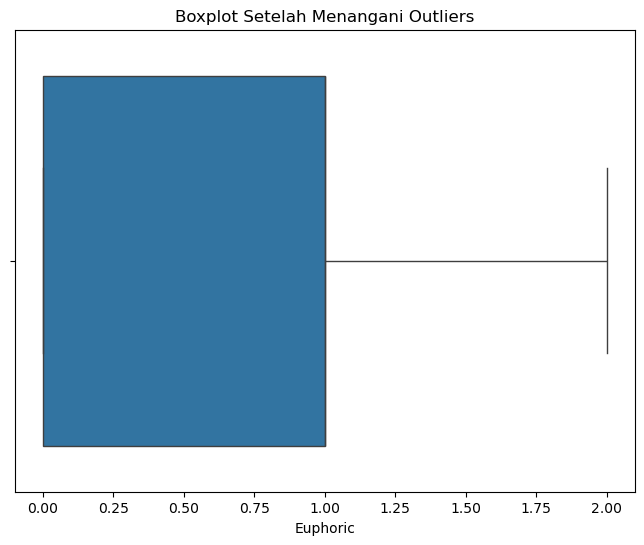

In [218]:
# Visualisasi boxplot setelah menangani outliers
plt.figure(figsize=(8, 6))
sns.boxplot(x=df['Euphoric'])
plt.title("Boxplot Setelah Menangani Outliers")
plt.show()



In [219]:
# Memisahkan fitur (X) dan target (y)
X = df.drop('Expert Diagnose', axis=1)
y = df['Expert Diagnose']

# Membagi data menjadi training dan testing set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Menampilkan ukuran dataset
print(f"Training data: {X_train.shape}, Test data: {X_test.shape}")

Training data: (96, 17), Test data: (24, 17)


In [220]:
# Normalisasi data
cols = X_train.columns

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

X_train = pd.DataFrame(X_train, columns=[cols])

X_test = pd.DataFrame(X_test, columns=[cols])

X_train.describe()

,Sadness,Euphoric,Exhausted,Sleep dissorder,Mood Swing,Suicidal thoughts,Anorxia,Authority Respect,Try-Explanation,Aggressive Response,Ignore & Move-On,Nervous Break-down,Admit Mistakes,Overthinking,Sexual Activity,Concentration,Optimisim
count,9.600000e+01,9.600000e+01,9.600000e+01,9.600000e+01,9.600000e+01,9.600000e+01,9.600000e+01,9.600000e+01,9.600000e+01,96.000000,9.600000e+01,9.600000e+01,9.600000e+01,9.600000e+01,96.000000,9.600000e+01,9.600000e+01
mean,7.864080e-17,-1.110223e-16,5.088522e-17,-1.850372e-17,7.401487e-17,1.572816e-16,-3.700743e-17,-6.013708e-17,-9.251859e-17,0.000000,6.013708e-17,7.401487e-17,5.551115e-17,3.700743e-17,0.000000,1.156482e-16,9.251859e-18
std,1.005249e+00,1.005249e+00,1.005249e+00,1.005249e+00,1.005249e+00,1.005249e+00,1.005249e+00,1.005249e+00,1.005249e+00,1.005249,1.005249e+00,1.005249e+00,1.005249e+00,1.005249e+00,1.005249,1.005249e+00,1.005249e+00
min,-1.687664e+00,-1.119948e+00,-1.576144e+00,-1.469468e+00,-1.021055e+00,-9.198662e-01,-7.745967e-01,-8.451543e-01,-9.591663e-01,-1.000000,-8.633971e-01,-9.793792e-01,-9.793792e-01,-1.087115e+00,-1.879902,-1.700231e+00,-1.763834e+00
25%,-5.779671e-01,-1.119948e+00,-5.999517e-01,-4.689790e-01,-1.021055e+00,-9.198662e-01,-7.745967e-01,-8.451543e-01,-9.591663e-01,-1.000000,-8.633971e-01,-9.793792e-01,-9.793792e-01,-1.087115e+00,-0.877288,-1.170289e+00,-7.559289e-01
50%,5.317297e-01,2.763508e-01,3.762409e-01,-4.689790e-01,9.793792e-01,-9.198662e-01,-7.745967e-01,-8.451543e-01,-9.591663e-01,0.000000,-8.633971e-01,-9.793792e-01,-9.793792e-01,9.198662e-01,0.125327,-1.104046e-01,0.000000e+00
75%,5.317297e-01,2.763508e-01,6.202891e-01,5.315096e-01,9.793792e-01,1.087115e+00,1.290994e+00,1.183216e+00,1.042572e+00,1.000000,1.158216e+00,1.021055e+00,1.021055e+00,9.198662e-01,0.626634,4.195375e-01,7.559289e-01
max,1.641427e+00,1.672650e+00,1.352434e+00,1.531998e+00,9.793792e-01,1.087115e+00,1.290994e+00,1.183216e+00,1.042572e+00,1.000000,1.158216e+00,1.021055e+00,1.021055e+00,9.198662e-01,2.130556,2.009364e+00,2.267787e+00


In [221]:
# Menampilkan distribusi kelas sebelum SMOTE
print("Distribusi kelas sebelum SMOTE:")
print(y_train.value_counts())

# Menggunakan SMOTE untuk menyeimbangkan data
from imblearn.over_sampling import SMOTE
smote = SMOTE(sampling_strategy='auto', random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)

# Menampilkan distribusi kelas setelah SMOTE
print("\nDistribusi kelas setelah SMOTE:")
print(y_res.value_counts())


Distribusi kelas sebelum SMOTE:
Expert Diagnose
Bipolar Type-2    26
Bipolar Type-1    24
Normal            23
Depression        23
Name: count, dtype: int64

Distribusi kelas setelah SMOTE:
Expert Diagnose
Normal            26
Bipolar Type-2    26
Bipolar Type-1    26
Depression        26
Name: count, dtype: int64


c:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


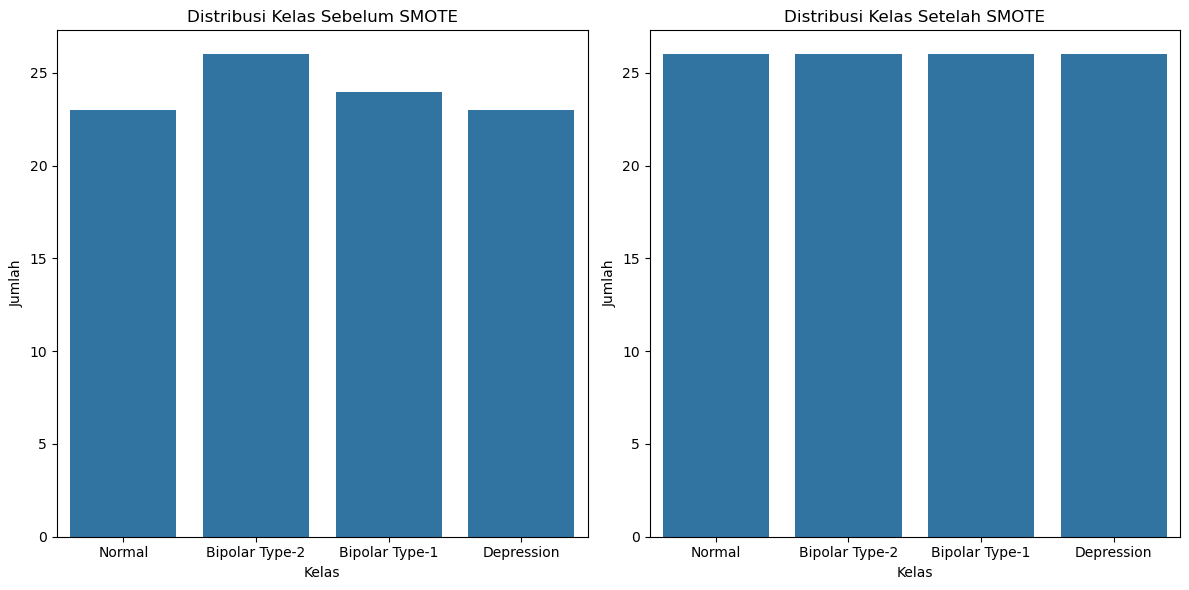

In [222]:
import matplotlib.pyplot as plt
import seaborn as sns

# Menampilkan distribusi kelas sebelum SMOTE
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)  # Mengatur plot menjadi dua kolom
sns.countplot(x=y_train)
plt.title('Distribusi Kelas Sebelum SMOTE')
plt.xlabel('Kelas')
plt.ylabel('Jumlah')

# Menampilkan distribusi kelas setelah SMOTE
plt.subplot(1, 2, 2)
sns.countplot(x=y_res)
plt.title('Distribusi Kelas Setelah SMOTE')
plt.xlabel('Kelas')
plt.ylabel('Jumlah')

plt.tight_layout()  # Menata agar plot tidak tumpang tindih
plt.show()


In [223]:
# Import SVC classifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Instantiate classifier with default hyperparameters
svc = SVC(probability=True, class_weight='balanced', random_state=42)

# Fit classifier to training set
svc.fit(X_train, y_train)

# Make predictions on test set
y_pred = svc.predict(X_test)

# Compute and print accuracy score
print('Model accuracy score with default hyperparameters: {0:0.4f}'.format(accuracy_score(y_test, y_pred)))

Model accuracy score with default hyperparameters: 0.8333


In [224]:
# instantiate classifier with linear kernel and C=1.0
linear_svc=SVC(kernel='linear', C=1.0) 


# fit classifier to training set
linear_svc.fit(X_train,y_train)


# make predictions on test set
y_pred_test=linear_svc.predict(X_test)


# compute and print accuracy score
print('Model accuracy score with linear kernel and C=1.0 : {0:0.4f}'. format(accuracy_score(y_test, y_pred_test)))

Model accuracy score with linear kernel and C=1.0 : 0.8750


In [225]:
# instantiate classifier with rbf kernel and C=1
svc=SVC(C=1.0) 


# fit classifier to training set
svc.fit(X_train,y_train)


# make predictions on test set
y_pred=svc.predict(X_test)


# compute and print accuracy score
print('Model accuracy score with rbf kernel and C=1.0 : {0:0.4f}'. format(accuracy_score(y_test, y_pred)))

Model accuracy score with rbf kernel and C=1.0 : 0.8333


In [226]:
# instantiate classifier with polynomial kernel and C=1.0
poly_svc=SVC(kernel='poly', C=1.0) 


# fit classifier to training set
poly_svc.fit(X_train,y_train)


# make predictions on test set
y_pred=poly_svc.predict(X_test)


# compute and print accuracy score
print('Model accuracy score with polynomial kernel and C=1.0 : {0:0.4f}'. format(accuracy_score(y_test, y_pred)))

Model accuracy score with polynomial kernel and C=1.0 : 0.7500


In [227]:
# instantiate classifier with sigmoid kernel and C=1.0
sigmoid_svc=SVC(kernel='sigmoid', C=1.0) 


# fit classifier to training set
sigmoid_svc.fit(X_train,y_train)


# make predictions on test set
y_pred=sigmoid_svc.predict(X_test)


# compute and print accuracy score
print('Model accuracy score with sigmoid kernel and C=1.0 : {0:0.4f}'. format(accuracy_score(y_test, y_pred)))

Model accuracy score with sigmoid kernel and C=1.0 : 0.8750


In [228]:
y_pred_train = linear_svc.predict(X_train)

y_pred_train

array(['Normal', 'Bipolar Type-2', 'Bipolar Type-1', 'Normal',
       'Depression', 'Normal', 'Bipolar Type-2', 'Normal', 'Normal',
       'Bipolar Type-1', 'Bipolar Type-1', 'Normal', 'Bipolar Type-1',
       'Bipolar Type-1', 'Depression', 'Depression', 'Bipolar Type-1',
       'Normal', 'Bipolar Type-1', 'Bipolar Type-2', 'Depression',
       'Bipolar Type-2', 'Depression', 'Depression', 'Bipolar Type-2',
       'Bipolar Type-2', 'Depression', 'Depression', 'Normal', 'Normal',
       'Normal', 'Bipolar Type-2', 'Normal', 'Bipolar Type-1',
       'Bipolar Type-1', 'Bipolar Type-1', 'Normal', 'Depression',
       'Normal', 'Bipolar Type-2', 'Bipolar Type-1', 'Bipolar Type-2',
       'Normal', 'Bipolar Type-1', 'Bipolar Type-2', 'Bipolar Type-1',
       'Normal', 'Bipolar Type-2', 'Bipolar Type-1', 'Bipolar Type-2',
       'Bipolar Type-2', 'Depression', 'Bipolar Type-2', 'Normal',
       'Bipolar Type-1', 'Normal', 'Bipolar Type-2', 'Depression',
       'Bipolar Type-1', 'Depression',

In [229]:
# print the scores on training and test set

print('Training set score: {:.4f}'.format(linear_svc.score(X_train, y_train)))

print('Test set score: {:.4f}'.format(linear_svc.score(X_test, y_test)))

Training set score: 1.0000
Test set score: 0.8750


In [230]:
# check class distribution in test set

y_test.value_counts()

Expert Diagnose
Depression        8
Normal            7
Bipolar Type-2    5
Bipolar Type-1    4
Name: count, dtype: int64

In [231]:
# Menghitung distribusi kelas di data uji
class_counts = y_test.value_counts()

# Mendapatkan jumlah kelas mayoritas
majority_class_count = class_counts.max()

# Menghitung jumlah total sampel di data uji
total_samples = len(y_test)

# Menghitung null accuracy
null_accuracy = majority_class_count / total_samples

# Menampilkan null accuracy
print(f"Null accuracy: {null_accuracy:.4f}")


Null accuracy: 0.3333


In [232]:
# Menggunakan GridSearchCV untuk mencari hyperparameter terbaik
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1],
    'kernel': ['linear', 'rbf', 'poly', 'sigmoid']
}

grid_search = GridSearchCV(SVC(class_weight='balanced', probability=True, random_state=42), param_grid, cv=5, n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

# Menampilkan best parameters dari grid search
print(f"Best parameters: {grid_search.best_params_}")

# Evaluasi model terbaik
best_model = grid_search.best_estimator_

# Melakukan prediksi pada test set
y_pred_best = best_model.predict(X_test)

# Accuracy evaluation
print(f"Accuracy: {accuracy_score(y_test, y_pred_best)}")

# Confusion matrix dan classification report
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_best))
print("Classification Report:\n", classification_report(y_test, y_pred_best))


Fitting 5 folds for each of 80 candidates, totalling 400 fits
Best parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Accuracy: 0.8333333333333334
Confusion Matrix:
 [[4 0 0 0]
 [0 5 0 0]
 [1 0 7 0]
 [1 0 2 4]]
Classification Report:
                 precision    recall  f1-score   support

Bipolar Type-1       0.67      1.00      0.80         4
Bipolar Type-2       1.00      1.00      1.00         5
    Depression       0.78      0.88      0.82         8
        Normal       1.00      0.57      0.73         7

      accuracy                           0.83        24
     macro avg       0.86      0.86      0.84        24
  weighted avg       0.87      0.83      0.83        24



In [ ]:
from sklearn.metrics import confusion_matrix

# Misal y_test dan y_pred_best sudah didefinisikan dan merupakan hasil dari prediksi terbaik Anda

# Daftar nama kelas
class_names = ['Bipolar Type-2',  'Depression', 'Bipolar Type-1', 'Normal']

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred_best)

# Print the confusion matrix
print('Confusion Matrix:\n', cm)

# Iterate over each class to extract TP, FN, FP, TN
for i in range(len(class_names)):
    TP = cm[i, i]  # True Positive
    FN = cm[i, :].sum() - TP  # False Negative
    FP = cm[:, i].sum() - TP  # False Positive
    TN = cm.sum() - (TP + FN + FP)  # True Negative

    print(f'{class_names[i]} - True Positives (TP): {TP}, False Negatives (FN): {FN}, False Positives (FP): {FP}, True Negatives (TN): {TN}')


Confusion Matrix:
 [[4 0 0 0]
 [0 5 0 0]
 [1 0 7 0]
 [1 0 2 4]]
Bipolar Type-2 - True Positives (TP): 4, False Negatives (FN): 0, False Positives (FP): 2, True Negatives (TN): 18
Depression - True Positives (TP): 5, False Negatives (FN): 0, False Positives (FP): 0, True Negatives (TN): 19
Bipolar Type-1 - True Positives (TP): 7, False Negatives (FN): 1, False Positives (FP): 2, True Negatives (TN): 14
Normal - True Positives (TP): 4, False Negatives (FN): 3, False Positives (FP): 0, True Negatives (TN): 17


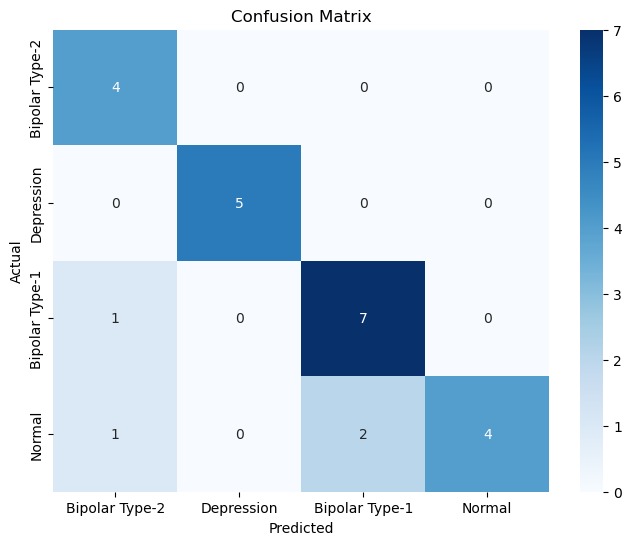

In [234]:
# Visualisasi confusion matrix
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=df['Expert Diagnose'].unique(), yticklabels=df['Expert Diagnose'].unique())
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [235]:
# Menampilkan 5 baris pertama dalam bentuk tabel
df.head()

,Sadness,Euphoric,Exhausted,Sleep dissorder,Mood Swing,Suicidal thoughts,Anorxia,Authority Respect,Try-Explanation,Aggressive Response,Ignore & Move-On,Nervous Break-down,Admit Mistakes,Overthinking,Sexual Activity,Concentration,Optimisim,Expert Diagnose
0,2,0.0,1,1,1,0,0,0,1,0,0,1,1,1,3,3,4,Bipolar Type-2
1,2,0.0,2,1,0,1,0,0,0,0,0,0,0,0,4,2,5,Depression
2,1,1.0,1,1,1,0,0,0,1,1,0,1,1,0,6,5,7,Bipolar Type-1
3,2,0.0,2,3,1,1,1,0,1,0,0,0,0,0,3,2,2,Bipolar Type-2
4,2,2.0,1,1,0,0,0,0,0,0,0,1,1,1,5,5,6,Normal


In [236]:
import numpy as np

# data pasien baru yang ingin diuji
new_patient_data = [
    2,  # Sadness: "Usually"
    0,  # Euphoric: "Sometimes"
    1,  # Exhausted: "Seldom"
    1,  # Sleep dissorder: "Sometimes"
    1,  # Mood Swing: YES (1)
    0,  # Suicidal thoughts: NO (0)
    0,  # Anorxia: NO (0)
    0,  # Authority Respect: YES (1)
    1,  # Try-Explanation: NO (0)
    0,  # Aggressive Response: YES (1)
    0,  # Ignore & Move-On: NO (0)
    1,  # Nervous Break-down: NO (0)
    1,  # Admit Mistakes: YES (1)
    1,  # Overthinking: NO (0)
    3,  # Sexual Activity: "6 From 10"
    3,  # Concentration: "5 From 10"
    4   # Optimisim: "4 From 10"
]

# Melakukan normalisasi pada data pasien baru menggunakan scaler yang sudah di-fit
new_patient_scaled = scaler.transform([new_patient_data])

# Melakukan prediksi dengan model terbaik (best_model adalah model yang sudah dilatih)
new_prediction = best_model.predict(new_patient_scaled)

# Menampilkan hasil prediksi
print(f"Hasil prediksi untuk data pasien baru: {new_prediction[0]}")


Hasil prediksi untuk data pasien baru: Bipolar Type-2


c:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


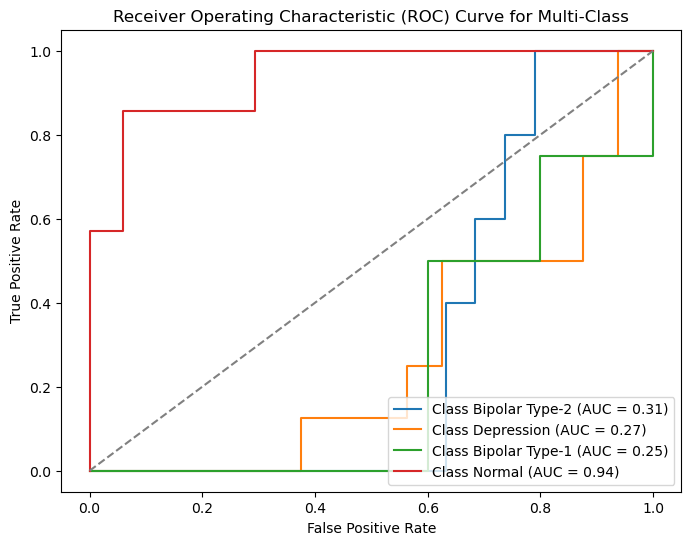

In [237]:
# Membuat ROC Curve
y_bin = label_binarize(y_test, classes=df['Expert Diagnose'].unique())
y_score = best_model.predict_proba(X_test)

plt.figure(figsize=(8, 6))
for i in range(len(df['Expert Diagnose'].unique())):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {df["Expert Diagnose"].unique()[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Multi-Class')
plt.legend(loc='lower right')
plt.show()

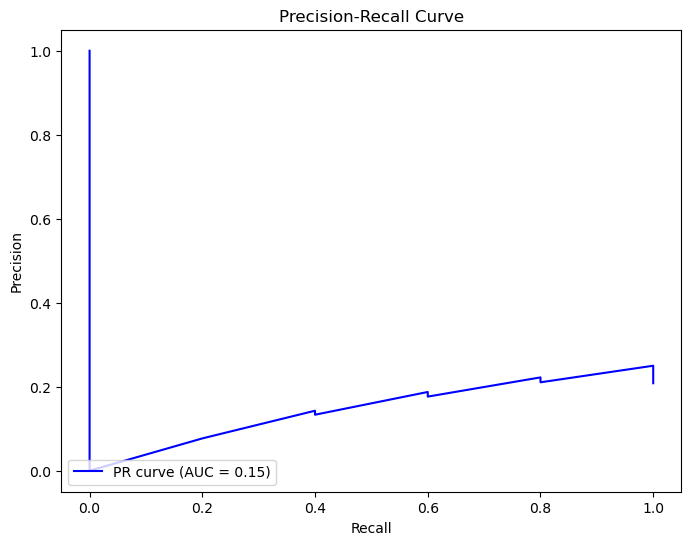

In [238]:
# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_bin[:, 0], y_score[:, 0])  # Misalkan kelas pertama
pr_auc = auc(recall, precision)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='blue', label=f'PR curve (AUC = {pr_auc:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
plt.show()